# Fixed-Size Shortest Paths / Dijkstra

Эксперимент `shortest_path_dijkstra/`: фиксированный weighted graph, output фиксированной длины `dist[0..N-1]`, auxiliary loss на внутреннее состояние алгоритма Дейкстры (`dist[]`, `visited[]`) на output-позициях.

## 0. Setup

In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
personal_token = user_secrets.get_secret("GITHUB_TOKEN")

!rm -rf transformer-analyzing
!git clone https://{personal_token}@github.com/maximvw/transformer-analyzing.git transformer-analyzing
%cd transformer-analyzing


import sys
from pathlib import Path
import json
import torch

print("Python:", sys.executable)
PYTHON = sys.executable
print("CUDA available:", torch.cuda.is_available())
print("CUDA devices:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {props.name} | {props.total_memory / 1e9:.1f} GB")

ROOT = Path.cwd()


Cloning into 'transformer-analyzing'...
remote: Enumerating objects: 561, done.
remote: Counting objects: 100% (223/223), done.
remote: Compressing objects: 100% (173/173), done.
remote: Total 561 (delta 85), reused 164 (delta 48), pack-reused 338 (from 1)
Receiving objects: 100% (561/561), 17.71 MiB | 28.74 MiB/s, done.
Resolving deltas: 100% (232/232), done.
/kaggle/working/transformer-analyzing
Python: /usr/bin/python3
CUDA available: True
CUDA devices: 2
GPU 0: Tesla T4 | 15.6 GB
GPU 1: Tesla T4 | 15.6 GB


## 1. Конфиг

Сверху есть переключатель `CONFIG_MODE`: `"smoke"` для быстрой проверки, что тетрадка запускается, и `"full"` для основного эксперимента.


In [2]:
CONFIG_MODE = "full"  # "smoke" | "full"

SMOKE_CONFIG = {
    "graph_n": 6,
    "max_weight": 5,
    "max_distance": 40,
    "max_seq_len": 64,
    "n_train": 256,
    "n_val": 64,
    "n_test": 64,
    "d_model": 16,
    "n_head": 4,
    "batch_size": 32,
    "epochs": 2,
    "patience": 1,
    "lr": 1e-4,
    "aux_lambdas": [0.1, 1.0, 10.0],
    "sft_layers": [2, 4, 6],
    "aux_layers": [2, 4, 6],
}

FULL_CONFIG = {
    "graph_n": 10,
    "max_weight": 9,
    "max_distance": 99,
    "max_seq_len": 128,
    "n_train": 80000,
    "n_val": 2000,
    "n_test": 2000,
    "d_model": 128,
    "n_head": 4,
    "batch_size": 128,
    "epochs": 50,
    "patience": 8,
    "lr": 1e-4,
    "aux_lambdas": [0.1, 1.0, 10.0],
    "sft_layers": [2, 4, 6],
    "aux_layers": [2, 4, 6],
}

CONFIGS = {
    "smoke": SMOKE_CONFIG,
    "full": FULL_CONFIG,
}
assert CONFIG_MODE in CONFIGS, f"Unknown CONFIG_MODE: {CONFIG_MODE}"
CFG = CONFIGS[CONFIG_MODE]

GRAPH_N = CFG["graph_n"]
MAX_WEIGHT = CFG["max_weight"]
MAX_DISTANCE = CFG["max_distance"]
MAX_SEQ_LEN = CFG["max_seq_len"]
N_TRAIN = CFG["n_train"]
N_VAL = CFG["n_val"]
N_TEST = CFG["n_test"]
D_MODEL = CFG["d_model"]
N_HEAD = CFG["n_head"]
BATCH_SIZE = CFG["batch_size"]
EPOCHS = CFG["epochs"]
PATIENCE = CFG["patience"]
LR = CFG["lr"]
AUX_LAMBDAS = CFG["aux_lambdas"]
SFT_LAYERS = CFG["sft_layers"]
AUX_LAYERS = CFG["aux_layers"]

RUN_TAG = f"{CONFIG_MODE}_n{GRAPH_N}"
DATA_DIR = ROOT / "shortest_path_dijkstra" / f"data_{RUN_TAG}"
CKPT_DIR = ROOT / "checkpoints" / f"shortest_path_dijkstra_{RUN_TAG}"
DATA_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f"CONFIG_MODE={CONFIG_MODE}")
print(json.dumps(CFG, indent=2))
print("DATA_DIR:", DATA_DIR)
print("CKPT_DIR:", CKPT_DIR)


CONFIG_MODE=full
{
  "graph_n": 10,
  "max_weight": 9,
  "max_distance": 99,
  "max_seq_len": 128,
  "n_train": 80000,
  "n_val": 2000,
  "n_test": 2000,
  "d_model": 128,
  "n_head": 4,
  "batch_size": 128,
  "epochs": 50,
  "patience": 8,
  "lr": 0.0001,
  "aux_lambdas": [
    0.1,
    1.0,
    10.0
  ],
  "sft_layers": [
    2,
    4,
    6
  ],
  "aux_layers": [
    2,
    4,
    6
  ]
}
DATA_DIR: /kaggle/working/transformer-analyzing/shortest_path_dijkstra/data_full_n10
CKPT_DIR: /kaggle/working/transformer-analyzing/checkpoints/shortest_path_dijkstra_full_n10


## 2. Генерация данных

In [3]:
!$PYTHON -m shortest_path_dijkstra.scripts.generate_data \
    --output_dir "$DATA_DIR" \
    --n_train $N_TRAIN \
    --n_val $N_VAL \
    --n_test $N_TEST \
    --graph_n $GRAPH_N \
    --edge_prob 0.25 \
    --dense_edge_prob 0.55 \
    --max_weight $MAX_WEIGHT \
    --max_distance $MAX_DISTANCE \
    --seed 42

for path in sorted(DATA_DIR.glob("*.json")):
    with open(path) as f:
        items = json.load(f)
    print(f"{path.name}: {len(items)} examples")
    if items:
        ex = items[0]
        print(" N:", ex["n"], "edges:", ex["num_edges"], "type:", ex["split_type"])
        print(" source:", ex["source"])
        print(" first row:", ex["matrix"][0])
        print(" distances:", ex["distances"])
        print(" first dist states:", ex["dist_states"][:2])

train: n=80000 | graph_N=10 | avg_edges=29.26 max_dist=56 | types={'random': 80000}
val: n=2000 | graph_N=10 | avg_edges=29.11 max_dist=43 | types={'random': 2000}
test_id: n=2000 | graph_N=10 | avg_edges=29.16 max_dist=52 | types={'random': 2000}
test_ood_dense: n=2000 | graph_N=10 | avg_edges=53.79 max_dist=20 | types={'dense': 2000}
test_ood_long_chain: n=2000 | graph_N=10 | avg_edges=14.07 max_dist=18 | types={'long_chain': 2000}
test_ood_adversarial_direct: n=2000 | graph_N=10 | avg_edges=20.45 max_dist=9 | types={'adversarial_direct': 2000}
test_ood_equal_ties: n=2000 | graph_N=10 | avg_edges=24.12 max_dist=18 | types={'equal_ties': 2000}
test_ood_layered_bipartite: n=2000 | graph_N=10 | avg_edges=25.83 max_dist=10 | types={'layered_bipartite': 2000}
test_ood_near_complete_hidden_path: n=2000 | graph_N=10 | avg_edges=90.00 max_dist=9 | types={'near_complete_hidden_path': 2000}
test_id.json: 2000 examples
 N: 10 edges: 30 type: random
 source: 0
 first row: [0, None, None, 1, 4, 8

## 3. SFT depth ablation

In [4]:
for n_layer in SFT_LAYERS:
    print(f"{'=' * 70}")
    print(f"Training Shortest Path SFT {n_layer}L")
    print(f"{'=' * 70}")
    SAVE_DIR = CKPT_DIR / f"dijkstra_sft_{n_layer}L"
    !"$PYTHON" -m shortest_path_dijkstra.src.train \
        --train_path "{DATA_DIR / 'train.json'}" \
        --val_path "{DATA_DIR / 'val.json'}" \
        --graph_n {GRAPH_N} \
        --max_weight {MAX_WEIGHT} \
        --max_distance {MAX_DISTANCE} \
        --d_model {D_MODEL} --n_layer {n_layer} --n_head {N_HEAD} \
        --max_seq_len {MAX_SEQ_LEN} \
        --lr {LR} --weight_decay 0.01 \
        --batch_size {BATCH_SIZE} --epochs {EPOCHS} --patience {PATIENCE} \
        --lambda_state 0.0 \
        --num_workers 2 \
        --save_dir "{SAVE_DIR}" \
        --seed 42

Training Shortest Path SFT 2L
Device: cuda
Vocab size: 127
Model parameters: 429,440
Using 2 GPUs with DataParallel
Epoch   0 | train loss=2.3174 tok_acc=0.3840 | val loss=1.7247 tok_acc=0.4815
Epoch   1 | train loss=1.6237 tok_acc=0.4883 | val loss=1.5774 tok_acc=0.4893
Epoch   2 | train loss=1.5397 tok_acc=0.4935 | val loss=1.5037 tok_acc=0.4990
Epoch   3 | train loss=1.4301 tok_acc=0.5130 | val loss=1.3376 tok_acc=0.5362
Epoch   4 | train loss=1.2462 tok_acc=0.5710 | val loss=1.1570 tok_acc=0.6069
Epoch   5 | train loss=1.0872 tok_acc=0.6321 | val loss=1.0040 tok_acc=0.6611
Epoch   6 | train loss=0.9469 tok_acc=0.6835 | val loss=0.8959 tok_acc=0.7006
Epoch   7 | train loss=0.8632 tok_acc=0.7133 | val loss=0.8313 tok_acc=0.7220
Epoch   8 | train loss=0.8116 tok_acc=0.7294 | val loss=0.7888 tok_acc=0.7354
Epoch   9 | train loss=0.7731 tok_acc=0.7401 | val loss=0.7555 tok_acc=0.7444
Epoch  10 | train loss=0.7368 tok_acc=0.7504 | val loss=0.7165 tok_acc=0.7532
Epoch  11 | train loss=0.7

## 4. Auxiliary Loss Across Depths

In [5]:
for n_layer in AUX_LAYERS:
    for aux_lambda in AUX_LAMBDAS:
        print(f"{'=' * 70}")
        print(f"Training Shortest Path {n_layer}L + Aux (lambda={aux_lambda})")
        print(f"{'=' * 70}")
        SAVE_DIR = CKPT_DIR / f"dijkstra_aux_{n_layer}L_lambda{aux_lambda}"
        !"$PYTHON" -m shortest_path_dijkstra.src.train \
            --train_path "{DATA_DIR / 'train.json'}" \
            --val_path "{DATA_DIR / 'val.json'}" \
            --graph_n {GRAPH_N} \
            --max_weight {MAX_WEIGHT} \
            --max_distance {MAX_DISTANCE} \
            --d_model {D_MODEL} --n_layer {n_layer} --n_head {N_HEAD} \
            --max_seq_len {MAX_SEQ_LEN} \
            --lr {LR} --weight_decay 0.01 \
            --batch_size {BATCH_SIZE} --epochs {EPOCHS} --patience {PATIENCE} \
            --lambda_state {aux_lambda} \
            --num_workers 2 \
            --save_dir "{SAVE_DIR}" \
            --seed 42

Training Shortest Path 2L + Aux (lambda=0.1)
Device: cuda
Vocab size: 127
Model parameters: 429,440
Probe parameters: 134,640
Using 2 GPUs with DataParallel
Epoch   0 | train loss=2.9097 tok_acc=0.2986 | val loss=2.4252 tok_acc=0.3965
Epoch   1 | train loss=2.1067 tok_acc=0.4644 | val loss=1.9639 tok_acc=0.4786
Epoch   2 | train loss=1.8863 tok_acc=0.4898 | val loss=1.8537 tok_acc=0.4913
Epoch   3 | train loss=1.7954 tok_acc=0.4986 | val loss=1.7392 tok_acc=0.5044
Epoch   4 | train loss=1.6769 tok_acc=0.5206 | val loss=1.6157 tok_acc=0.5356
Epoch   5 | train loss=1.5645 tok_acc=0.5562 | val loss=1.5128 tok_acc=0.5780
Epoch   6 | train loss=1.4688 tok_acc=0.5919 | val loss=1.4264 tok_acc=0.6048
Epoch   7 | train loss=1.4076 tok_acc=0.6121 | val loss=1.3780 tok_acc=0.6222
Epoch   8 | train loss=1.3556 tok_acc=0.6294 | val loss=1.3372 tok_acc=0.6357
Epoch   9 | train loss=1.3114 tok_acc=0.6435 | val loss=1.2902 tok_acc=0.6502
Epoch  10 | train loss=1.2775 tok_acc=0.6536 | val loss=1.2586 

## 5. Продолжение обучения с чекпоинта

В каждом `SAVE_DIR` хранится только один лучший чекпоинт: `checkpoint_best.pt`. При новом улучшении он перезаписывается, поэтому на Kaggle не копятся десятки моделей.

In [6]:
# # Продолжить SFT:
# n_layer = 6
# SAVE_DIR = CKPT_DIR / f"dijkstra_sft_{n_layer}L"
# RESUME_FROM = SAVE_DIR / "checkpoint_best.pt"
# EPOCHS = 80
# !"$PYTHON" -m shortest_path_dijkstra.src.train \
#     --train_path "{DATA_DIR / 'train.json'}" \
#     --val_path "{DATA_DIR / 'val.json'}" \
#     --graph_n {GRAPH_N} \
#     --max_weight {MAX_WEIGHT} \
#     --max_distance {MAX_DISTANCE} \
#     --d_model {D_MODEL} --n_layer {n_layer} --n_head {N_HEAD} \
#     --max_seq_len {MAX_SEQ_LEN} \
#     --lr {LR} --weight_decay 0.01 \
#     --batch_size {BATCH_SIZE} --epochs {EPOCHS} --patience {PATIENCE} \
#     --lambda_state 0.0 \
#     --num_workers 2 \
#     --save_dir "{SAVE_DIR}" \
#     --resume_from "{RESUME_FROM}" \
#     --seed 42

# # Продолжить Aux:
# n_layer = 6
# aux_lambda = 1.0
# SAVE_DIR = CKPT_DIR / f"dijkstra_aux_{n_layer}L_lambda{aux_lambda}"
# RESUME_FROM = SAVE_DIR / "checkpoint_best.pt"
# EPOCHS = 80
# !"$PYTHON" -m shortest_path_dijkstra.src.train \
#     --train_path "{DATA_DIR / 'train.json'}" \
#     --val_path "{DATA_DIR / 'val.json'}" \
#     --graph_n {GRAPH_N} \
#     --max_weight {MAX_WEIGHT} \
#     --max_distance {MAX_DISTANCE} \
#     --d_model {D_MODEL} --n_layer {n_layer} --n_head {N_HEAD} \
#     --max_seq_len {MAX_SEQ_LEN} \
#     --lr {LR} --weight_decay 0.01 \
#     --batch_size {BATCH_SIZE} --epochs {EPOCHS} --patience {PATIENCE} \
#     --lambda_state {aux_lambda} \
#     --num_workers 2 \
#     --save_dir "{SAVE_DIR}" \
#     --resume_from "{RESUME_FROM}" \
#     --seed 42

## 6. Evaluation

In [7]:
from shortest_path_dijkstra.src.evaluate import evaluate_all

all_eval = {}

for n_layer in SFT_LAYERS:
    name = f"SFT {n_layer}L"
    print(f"\n{'=' * 70}")
    print(name)
    print(f"{'=' * 70}")
    all_eval[name] = evaluate_all(
        checkpoint_path=str(CKPT_DIR / f"dijkstra_sft_{n_layer}L" / "checkpoint_best.pt"),
        data_dir=str(DATA_DIR),
        batch_size=BATCH_SIZE,
        lambda_state=0.0,
        graph_n=GRAPH_N,
        max_weight=MAX_WEIGHT,
        max_distance=MAX_DISTANCE,
        d_model=D_MODEL,
        n_layer=n_layer,
        n_head=N_HEAD,
        max_seq_len=MAX_SEQ_LEN,
    )

for n_layer in AUX_LAYERS:
    for aux_lambda in AUX_LAMBDAS:
        name = f"{n_layer}L + Aux (lambda={aux_lambda})"
        print(f"\n{'=' * 70}")
        print(name)
        print(f"{'=' * 70}")
        all_eval[name] = evaluate_all(
            checkpoint_path=str(CKPT_DIR / f"dijkstra_aux_{n_layer}L_lambda{aux_lambda}" / "checkpoint_best.pt"),
            data_dir=str(DATA_DIR),
            batch_size=BATCH_SIZE,
            lambda_state=aux_lambda,
            graph_n=GRAPH_N,
            max_weight=MAX_WEIGHT,
            max_distance=MAX_DISTANCE,
            d_model=D_MODEL,
            n_layer=n_layer,
            n_head=N_HEAD,
            max_seq_len=MAX_SEQ_LEN,
        )


SFT 2L
test_id: exact_match=0.5055 distance_acc=0.9058 token_acc=0.9269 ntp_loss=0.2215 state_loss=0.0000 (n=2000)
test_ood_adversarial_direct: exact_match=0.0140 distance_acc=0.6076 token_acc=0.7831 ntp_loss=0.7912 state_loss=0.0000 (n=2000)
test_ood_dense: exact_match=0.6610 distance_acc=0.9527 token_acc=0.9615 ntp_loss=0.1069 state_loss=0.0000 (n=2000)
test_ood_equal_ties: exact_match=0.9895 distance_acc=0.9990 token_acc=0.9990 ntp_loss=0.0085 state_loss=0.0000 (n=2000)
test_ood_layered_bipartite: exact_match=0.8655 distance_acc=0.9860 token_acc=0.9873 ntp_loss=0.0387 state_loss=0.0000 (n=2000)
test_ood_long_chain: exact_match=0.0575 distance_acc=0.6614 token_acc=0.7985 ntp_loss=0.6925 state_loss=0.0000 (n=2000)
test_ood_near_complete_hidden_path: exact_match=0.0055 distance_acc=0.5533 token_acc=0.7574 ntp_loss=1.4712 state_loss=0.0000 (n=2000)

SFT 4L
test_id: exact_match=0.6720 distance_acc=0.9440 token_acc=0.9521 ntp_loss=0.1363 state_loss=0.0000 (n=2000)
test_ood_adversarial_di

In [8]:
import pandas as pd

pd.set_option("display.max_rows", 100)

rows = []
for model_name, result in all_eval.items():
    for split, metrics in result.items():
        rows.append({
            "model": model_name,
            "split": split,
            "exact_match": metrics["exact_match"],
            "distance_accuracy": metrics["distance_accuracy"],
            "token_accuracy": metrics["token_accuracy"],
            "ntp_loss": metrics["loss_main"],
            "total_loss": metrics["loss"],
            "loss_state": metrics["loss_state"],
        })
df = pd.DataFrame(rows)
df

,model,split,exact_match,distance_accuracy,token_accuracy,ntp_loss,total_loss,loss_state
0,SFT 2L,test_id,0.5055,0.90575,0.926864,0.221455,0.221455,0.000000
1,SFT 2L,test_ood_adversarial_direct,0.0140,0.60760,0.783136,0.791203,0.791203,0.000000
2,SFT 2L,test_ood_dense,0.6610,0.95275,0.961545,0.106937,0.106937,0.000000
3,SFT 2L,test_ood_equal_ties,0.9895,0.99895,0.999045,0.008509,0.008509,0.000000
4,SFT 2L,test_ood_layered_bipartite,0.8655,0.98600,0.987273,0.038669,0.038669,0.000000
5,SFT 2L,test_ood_long_chain,0.0575,0.66140,0.798455,0.692516,0.692516,0.000000
6,SFT 2L,test_ood_near_complete_hidden_path,0.0055,0.55330,0.757409,1.471248,1.471248,0.000000
7,SFT 4L,test_id,0.6720,0.94405,0.952091,0.136301,0.136301,0.000000
8,SFT 4L,test_ood_adversarial_direct,0.0220,0.61285,0.705455,1.144640,1.144640,0.000000
9,SFT 4L,test_ood_dense,0.8375,0.97930,0.981682,0.049693,0.049693,0.000000


## 7. Training curves

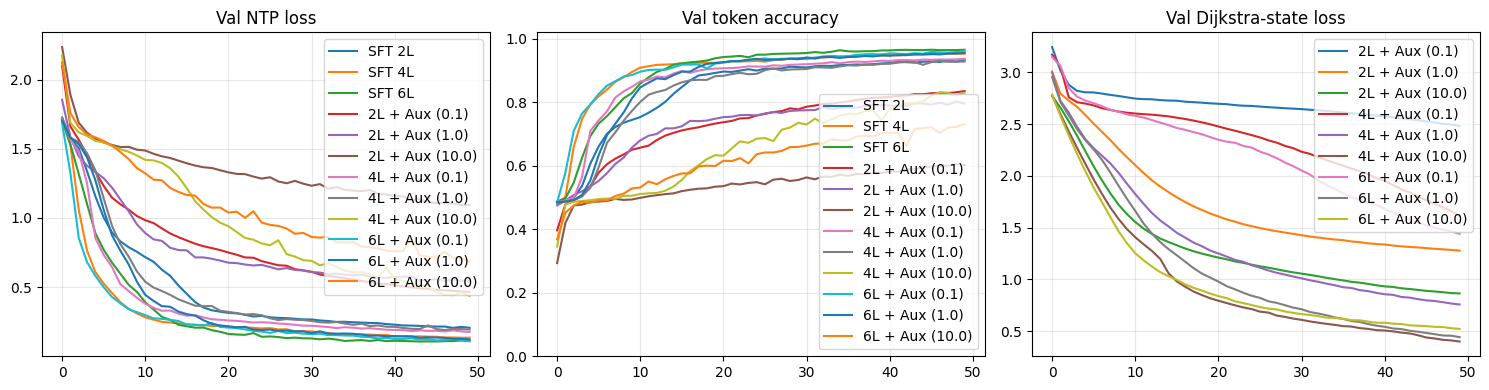

In [9]:
import matplotlib.pyplot as plt

def load_log(path):
    with open(path) as f:
        return json.load(f)

logs = {
    **{
        f"SFT {n_layer}L": load_log(CKPT_DIR / f"dijkstra_sft_{n_layer}L" / "train_log.json")
        for n_layer in SFT_LAYERS
    },
    **{
        f"{n_layer}L + Aux ({aux_lambda})": load_log(
            CKPT_DIR / f"dijkstra_aux_{n_layer}L_lambda{aux_lambda}" / "train_log.json"
        )
        for n_layer in AUX_LAYERS
        for aux_lambda in AUX_LAMBDAS
    },
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for label, log in logs.items():
    epochs = [row["epoch"] for row in log]
    axes[0].plot(epochs, [row["val"]["loss_main"] for row in log], label=label)
    axes[1].plot(epochs, [row["val"]["token_accuracy"] for row in log], label=label)
    if any(row["val"]["loss_state"] > 0 for row in log):
        axes[2].plot(epochs, [row["val"]["loss_state"] for row in log], label=label)

axes[0].set_title("Val NTP loss")
axes[1].set_title("Val token accuracy")
axes[1].set_ylim(0.0, 1.02)
axes[2].set_title("Val Dijkstra-state loss")
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()

## 8. Split Heatmaps

Сразу две защитные картинки: exact match и distance-wise accuracy на всех fixed-size split'ах.

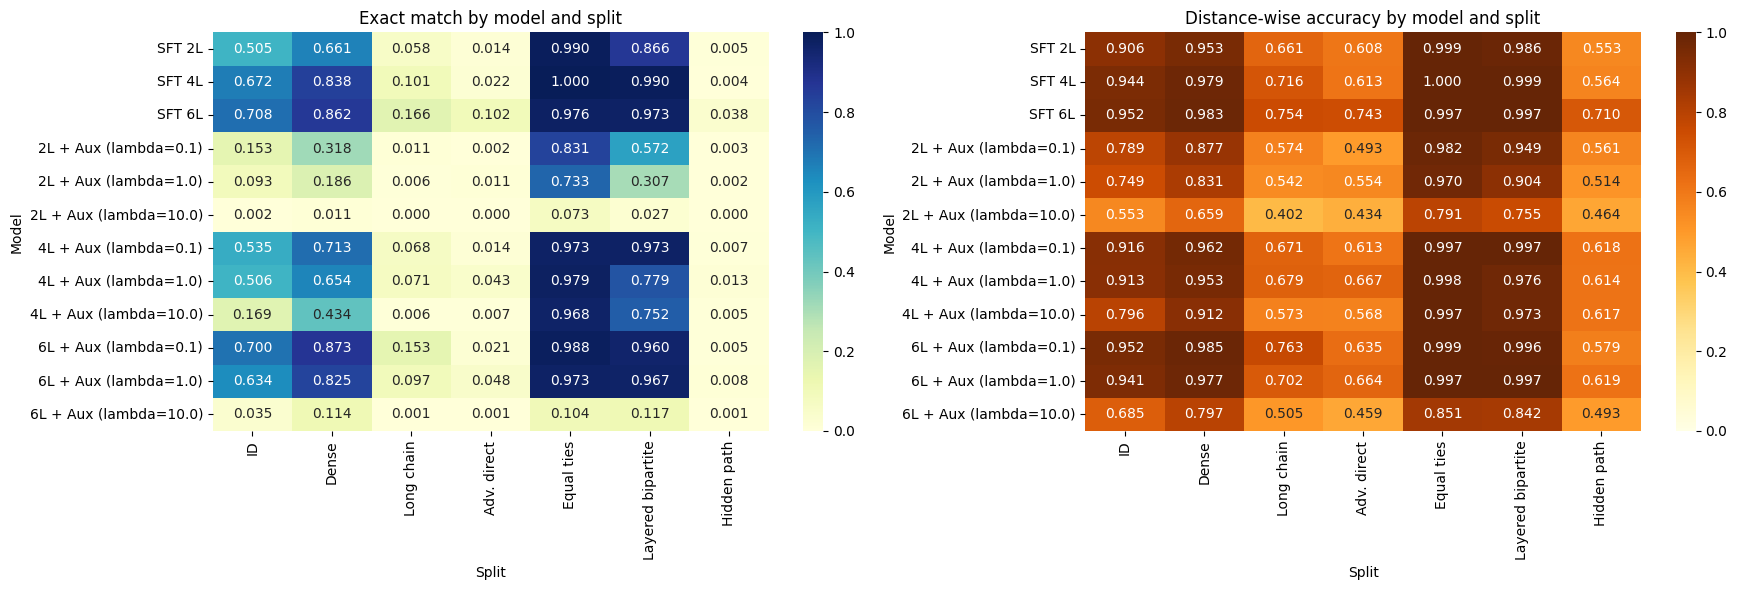

In [10]:
import seaborn as sns
import numpy as np

split_order = [
    "test_id",
    "test_ood_dense",
    "test_ood_long_chain",
    "test_ood_adversarial_direct",
    "test_ood_equal_ties",
    "test_ood_layered_bipartite",
    "test_ood_near_complete_hidden_path",
]
split_labels = {
    "test_id": "ID",
    "test_ood_dense": "Dense",
    "test_ood_long_chain": "Long chain",
    "test_ood_adversarial_direct": "Adv. direct",
    "test_ood_equal_ties": "Equal ties",
    "test_ood_layered_bipartite": "Layered bipartite",
    "test_ood_near_complete_hidden_path": "Hidden path",
}

exact_df = pd.DataFrame(
    {
        model_name: {
            split_labels[split]: all_eval[model_name][split]["exact_match"]
            for split in split_order
            if split in all_eval[model_name]
        }
        for model_name in all_eval
    }
).T
distance_df = pd.DataFrame(
    {
        model_name: {
            split_labels[split]: all_eval[model_name][split]["distance_accuracy"]
            for split in split_order
            if split in all_eval[model_name]
        }
        for model_name in all_eval
    }
).T

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(exact_df, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0.0, vmax=1.0, ax=axes[0])
axes[0].set_title("Exact match by model and split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Model")

sns.heatmap(distance_df, annot=True, fmt=".3f", cmap="YlOrBr", vmin=0.0, vmax=1.0, ax=axes[1])
axes[1].set_title("Distance-wise accuracy by model and split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Model")

plt.tight_layout()
plt.show()


## 9. OOD Gap Relative to ID

Эти графики удобны, когда хочется показать не только абсолютное качество, но и устойчивость модели при сдвиге распределения.

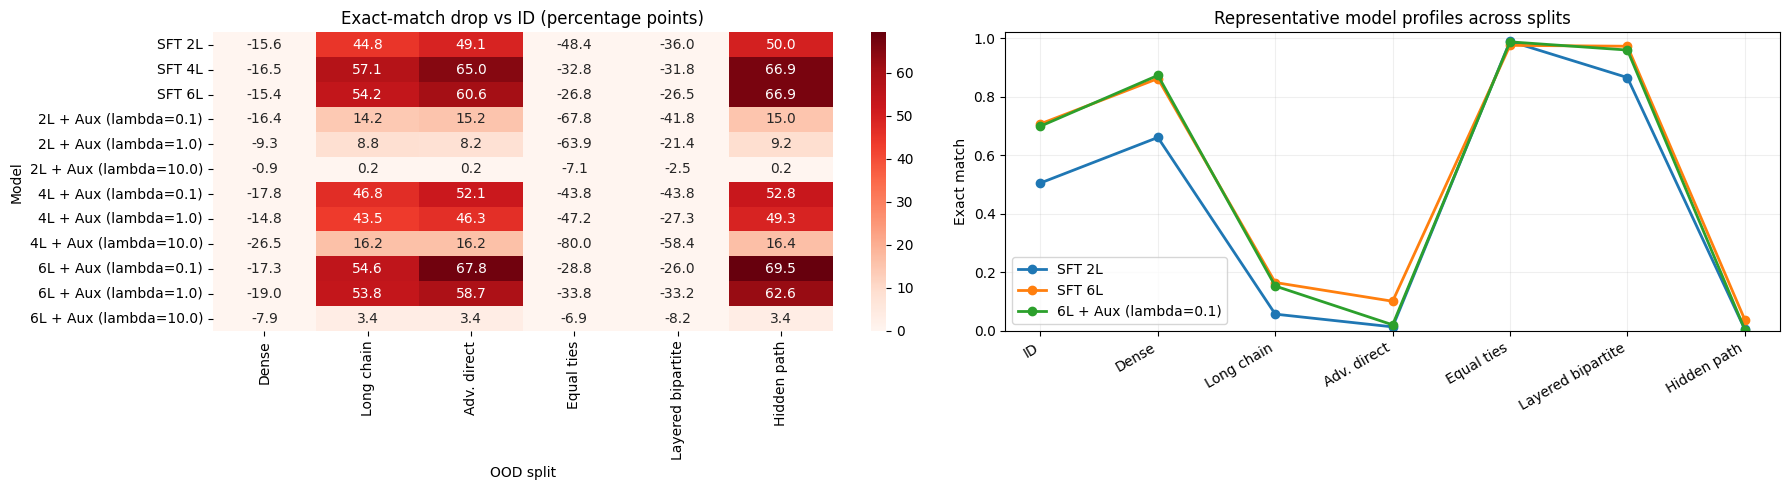

In [11]:
id_scores = exact_df["ID"]
drop_df = exact_df.apply(lambda col: id_scores - col)
ood_drop_df = drop_df[[col for col in exact_df.columns if col != "ID"]]

aux_candidates = [name for name in all_eval if " + Aux " in name]
best_aux_name = max(
    aux_candidates,
    key=lambda name: np.mean([all_eval[name][split]["exact_match"] for split in split_order if split != "test_id"]),
)

representative_models = []
for candidate in [f"SFT {SFT_LAYERS[0]}L", f"SFT {SFT_LAYERS[-1]}L", best_aux_name]:
    if candidate in all_eval and candidate not in representative_models:
        representative_models.append(candidate)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.heatmap(ood_drop_df * 100, annot=True, fmt=".1f", cmap="Reds", vmin=0.0, ax=axes[0])
axes[0].set_title("Exact-match drop vs ID (percentage points)")
axes[0].set_xlabel("OOD split")
axes[0].set_ylabel("Model")

x = np.arange(len(split_order))
for model_name in representative_models:
    ys = [all_eval[model_name][split]["exact_match"] for split in split_order]
    axes[1].plot(x, ys, marker="o", linewidth=2, label=model_name)
axes[1].set_xticks(x)
axes[1].set_xticklabels([split_labels[split] for split in split_order], rotation=30, ha="right")
axes[1].set_ylim(0.0, 1.02)
axes[1].set_ylabel("Exact match")
axes[1].set_title("Representative model profiles across splits")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()